# Import des bibliothèques nécessaires

In [11]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import gensim
from collections import defaultdict
from gensim import corpora
import re
from gensim.models import LdaModel
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Chargement du modèle de langue français de spaCy

In [12]:
nlp = spacy.load("fr_core_news_lg")
nlp_trf = spacy.load("fr_dep_news_trf")

In [13]:
dossier_path = Path("/Users/morganr/Champs_lexicaux_N-A/corpus_goncourt")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
        })
      
         

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

df

10 textes chargés avec succès.


,nom_fichier,texte_brut
0,1869_madame_gervaisais_travail.txt,"— Quarante scudi ?\n— Oui, signora.\n— Cela fa..."
1,1884_cherie_travail.txt,"petites amies à peu près de son âge, des place..."
2,1861_sœur_philomène_travail.txt,"La salle est haute et vaste. Elle est longue, ..."
3,1879_frères_zemganno_travail.txt,"En pleine campagne, au pied d’un poteau d’octr..."
4,1877_la_fille_elisa_travail.txt,"La femme, la prostituée condamnée à mort, étai..."
5,1865_germinie_lacerteux_travail.txt,"— Sauvée ! vous voilà donc sauvée, mademoisell..."
6,1867_manette_salomon_travail.txt,On était au commencement de novembre. La derni...
7,1860_Charles Demailly_travail.txt,– Un article ?… Tu me demandes s’ y a un artic...
8,1882_la_faustin_travail.txt,"faisait nuit sous un ciel étoilé, au-dessus d'..."
9,1864_renée_mauperin_travail.txt,"— Vous n’aimez pas le monde, mademoiselle ?\n—..."


In [14]:
def segmenter_texte(text, taille=400):
    mots = text.split()
    segments = []
    for i in range(0, len(mots), taille):
        segment = " ".join(mots[i:i+taille])
        if len(segment.split()) >= 100: 
            segments.append(segment)
    return segments

In [15]:
lignes = []

for _, row in df.iterrows():
    titre = row["nom_fichier"]
    texte = row["texte_brut"]
    segments = segmenter_texte(texte)
    
    for j, seg in enumerate(segments):
        lignes.append({
            "titre": titre,
            "segment_id": j,
            "texte_segment": seg
        })

df_segments = pd.DataFrame(lignes)

In [16]:
df_segments

,titre,segment_id,texte_segment
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait..."
1,1869_madame_gervaisais_travail.txt,1,d’étrangers à Rome… — Dites-moi : la maison es...
2,1869_madame_gervaisais_travail.txt,2,"Je dois vous prévenir pour les scarpe, les sou..."
3,1869_madame_gervaisais_travail.txt,3,place des touristes consciencieux lisaient le ...
4,1869_madame_gervaisais_travail.txt,4,"Des paroles professorales, de grossières ignor..."
...,...,...,...
1708,1864_renée_mauperin_travail.txt,163,un vilain papa qui me trouve toujours mauvaise...
1709,1864_renée_mauperin_travail.txt,164,!… Oh ! je voudrais que ce fût demain… Je n’en...
1710,1864_renée_mauperin_travail.txt,165,disaient bientôt plus rien ; ils restaient mue...
1711,1864_renée_mauperin_travail.txt,166,"le cadre était incliné, semblait se pencher su..."


In [17]:
def nettoyer_texte(texte):
    doc = nlp(texte)
    tokens = []
    
    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.like_num
            and not token.is_space
            and token.pos_ in {"NOUN", "ADJ"}
            and len(token.lemma_) > 2
        ):
            tokens.append(token.lemma_.lower())
    
    return " ".join(tokens)

In [18]:
df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte)

df_segments[["texte_segment", "texte_nettoye"]].head()

,texte_segment,texte_nettoye
0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...
1,d’étrangers à Rome… — Dites-moi : la maison es...,étranger dite maison tranquille bruit heure ma...
2,"Je dois vous prévenir pour les scarpe, les sou...",scarpe soulier femme chambre femme chambre lit...
3,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...
4,"Des paroles professorales, de grossières ignor...",parole professoral grossier ignorance mœur hab...


In [19]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(1713, 4495)

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


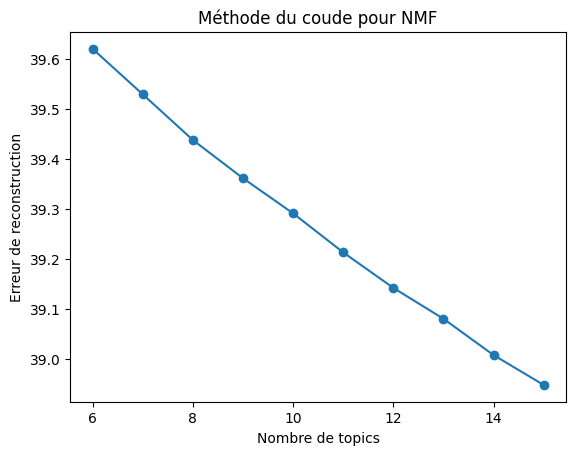

In [20]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

ks = range(6, 16)
errors = []

for k in ks:
    nmf = NMF(n_components=k, random_state=42)
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.plot(list(ks), errors, marker='o')
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

# Choix de k = 8

In [21]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=8, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : homme | franc | journal | art | argent | grand | atelier | ami | idée | talent
Topic 2 : monsieur | renée | cher | femme | homme | voix | vrai | monde | vou | abbé
Topic 3 : femme | amour | homme | vie | pensée | cœur | jeune | parole | âme | esprit
Topic 4 : sœur | lit | malade | salle | interne | hôpital | médecin | heure | mort | jour
Topic 5 : enfant | mère | petit | fille | père | mme | fils | bon | jeune | maréchal
Topic 6 : frère | cirque | exercice | saut | tour | pied | clown | aîné | directeur | jour
Topic 7 : femme | petit | main | tête | oeil | cheveu | bras | corps | blanc | noir
Topic 8 : eau | ciel | arbre | grand | soleil | ombre | blanc | bois | lumière | jour


In [22]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : franc | bon | rue | dîner | maison | heure | argent | jour | porte | cent
Topic 2 : monsieur | renée | femme | cher | voix | vrai | vou | monde | abbé | homme
Topic 3 : femme | amour | vie | pensée | cœur | homme | parole | âme | mort | jour
Topic 4 : sœur | lit | malade | salle | interne | hôpital | médecin | rideau | garde | voix
Topic 5 : enfant | mère | fille | petit | père | mme | jeune | fils | maréchal | grand
Topic 6 : frère | cirque | exercice | saut | tour | pied | clown | aîné | directeur | jour
Topic 7 : femme | petit | main | tête | oeil | cheveu | bras | corps | blanc | noir
Topic 8 : eau | arbre | ciel | grand | soleil | blanc | ombre | bois | terre | lumière
Topic 9 : homme | journal | livre | monde | théâtre | grand | esprit | cher | ami | public
Topic 10 : art | tableau | atelier | peintre | artiste | toile | peinture | talent | modèle | dessin


In [23]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=12, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : franc | bon | rue | dîner | maison | heure | argent | jour | cent | porte
Topic 2 : monsieur | femme | voix | abbé | monde | cher | vrai | vou | homme | mari
Topic 3 : vie | femme | amour | pensée | mort | cœur | parole | âme | jour | corps
Topic 4 : sœur | lit | malade | salle | interne | hôpital | médecin | rideau | garde | voix
Topic 5 : enfant | mère | mme | petit | fils | pauvre | tante | père | église | cœur
Topic 6 : frère | cirque | exercice | saut | tour | pied | clown | aîné | directeur | tonneau
Topic 7 : femme | petit | main | tête | oeil | cheveu | bras | corps | noir | blanc
Topic 8 : eau | arbre | ciel | grand | soleil | blanc | bois | ombre | terre | lumière
Topic 9 : fille | jeune | maréchal | femme | petit | mariage | grand | père | année | monde
Topic 10 : art | tableau | atelier | artiste | peintre | toile | peinture | talent | modèle | dessin
Topic 11 : renée | père | papa | denoisel | maman | main | fille | oeil | rire | beau
Topic 12 : homme | journal |

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
